In [1]:
import ase.io
import ase
import pickle
import numpy as np
import matplotlib.pyplot as plt
from metropolis import MetropolisCalculator
from trial_moves import nudge_orientation
from potentials import quadrupole_potential, gay_berne_walsh
from scipy.spatial.transform import Rotation

In [2]:
frames = ase.io.read("xyz_files/duped_benzenes.xyz", ":")
ell_frames = ase.io.read("xyz_files/duped_ellipsoids_with_axes.xyz", ":")
print("frames length: ", len(frames))
print("ell_frames length: ", len(ell_frames))

frames length:  6826
ell_frames length:  6826


In [3]:
def run_simulation(length, simulation_id=None, init_frame_idx=0):
    metro = MetropolisCalculator(ell_frames[init_frame_idx], energy_func="Walsh", pos_delt = 0.5, or_delt=0.2)
    metro.calculate_trajectory(length)
    return metro

metro = run_simulation(1000)
ase.io.write("simulations/testing/run_dupe.xyz", metro.frames)

old energy: 6.207911917070044e-43
 new energy: 6.004725336795264e-43
Boltz: 1.0
old energy: 3.1273971702496862e-43
 new energy: 2.6328435295965806e-43
Boltz: 1.0
old energy: 6.203796944248474e-43
 new energy: 6.0070883791226756e-43
Boltz: 1.0
old energy: 6.202308249626942e-43
 new energy: 5.865558222567981e-43
Boltz: 1.0
old energy: 3.1949449457631984e-43
 new energy: 3.168866088027594e-43
Boltz: 1.0
old energy: 3.119570434243434e-43
 new energy: 2.9517232736128484e-43
Boltz: 1.0
old energy: 6.198426493524009e-43
 new energy: 5.870833414602879e-43
Boltz: 1.0
old energy: 6.2041678310121315e-43
 new energy: 5.7696559279677964e-43
Boltz: 1.0
old energy: 3.298562085114873e-43
 new energy: 2.9872318390852104e-43
Boltz: 1.0
old energy: 3.109536984809981e-43
 new energy: 3.1468194174392385e-43
Boltz: 1.0
old energy: 2.9544274330325307e-43
 new energy: 3.135470512606479e-43
Boltz: 1.0
old energy: 6.226183426168608e-43
 new energy: 7.265443981846336e-43
Boltz: 1.0
old energy: 6.202059950748373e

KeyboardInterrupt: 

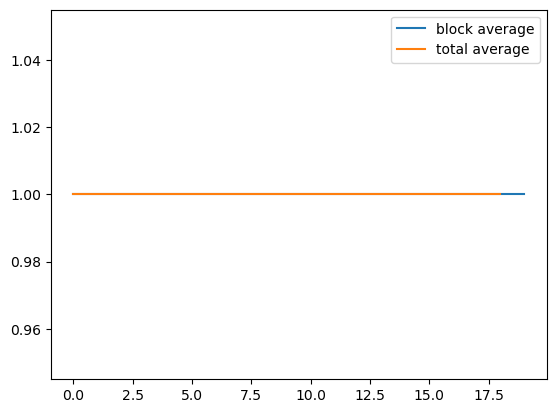

In [4]:
# plot average move acceptance rate
block_avgs = []
total_avgs = []
final_n = -1
n = 1
decisions = [dec.value for dec in metro.decisions]
while n < len(decisions[1:]) / 50:
    start = (n-1)*50 + 1
    stop = n*50 + 1
    avg = np.mean(decisions[start:stop])
    block_avgs.append(avg)
    total_avgs.append(metro.get_acc_rate(at_step=(50*n)+1))
    final_n = n
    n += 1
block_avgs.append(np.mean(decisions[final_n*50 + 1:]))
block_avgs = np.array(block_avgs)
plt.plot(block_avgs, label="block average")
plt.plot(total_avgs, label="total average")
plt.legend()
plt.show()

In [6]:
# record simulation trajectory as XYZ file
ase.io.write(f"simulations/testing/traj.xyz", metro.frames)

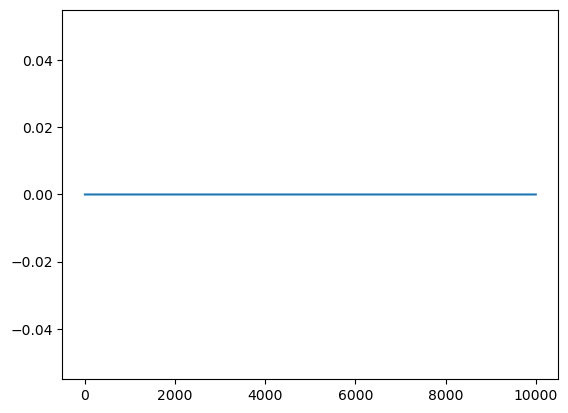

In [7]:
# Check that orientation is being updated
old_frame = metro.frames[0]
orientation_changes = []
for frame in metro.frames[1:]:
    old_ors = old_frame.arrays["or_vec"]
    new_ors = frame.arrays["or_vec"]
    orientation_changes.append(np.linalg.norm(new_ors - old_ors))

plt.plot(orientation_changes)

In [8]:
orientation_updates = [ell_frames[0]]
length = 100
i = 0
while i < length:
    nframe = nudge_orientation(orientation_updates[i], 0, 0.1)
    orientation_updates.append(nframe)
    i += 1

ase.io.write("simulations/testing/orientation_updates.xyz", orientation_updates)

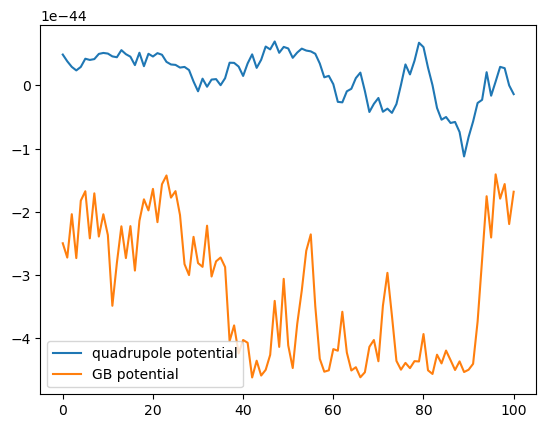

In [9]:
quadrupole_energies = [quadrupole_potential(frame) for frame in orientation_updates]
gb_energies = [gay_berne_walsh(frame) for frame in orientation_updates]
plt.plot(quadrupole_energies, label="quadrupole potential")
plt.plot(gb_energies, label="GB potential")
plt.legend()
plt.show()

In [10]:
orientation_updates = ase.io.read("simulations/testing/orientation_updates.xyz", ":")
for i, frame in enumerate(orientation_updates):
    R1 = Rotation.from_quat(np.roll(frame.arrays["c_q"][0], -1))
    R2 = Rotation.from_quat(np.roll(frame.arrays["c_q"][1], -1))
    or_vec1 = R1.as_matrix() @ [[0], [0], [1]]
    or_vec2 = R2.as_matrix() @ [[0], [0], [1]]
    frame.arrays["or_vec"][0] = or_vec1.flatten()
    frame.arrays["or_vec"][1] = or_vec2.flatten()
ase.io.write("simulations/testing/or_vecs.xyz", orientation_updates)